In [3]:
import pandas as pd

In [4]:
data = pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv")

In [5]:
data.rename(columns={
    "work_year": "ano_de_trabalho",
    "experience_level": "nivel_de_experiencia",
    "employment_type": "tipo_de_emprego",
    "job_title": "cargo",
    "salary": "salario",
    "salary_currency": "moeda_do_salario",
    "salary_in_usd": "salario_em_usd",
    "employee_residence": "residencia_do_funcionario",
    "remote_ratio": "percentual_remoto",
    "company_location": "localizacao_da_empresa",
    "company_size": "tamanho_da_empresa",
}, inplace=True)

In [6]:
data.columns

Index(['ano_de_trabalho', 'nivel_de_experiencia', 'tipo_de_emprego', 'cargo',
       'salario', 'moeda_do_salario', 'salario_em_usd',
       'residencia_do_funcionario', 'percentual_remoto',
       'localizacao_da_empresa', 'tamanho_da_empresa'],
      dtype='str')

In [26]:
_anos = dict[int, int]()
_empregos = dict[str, dict[int, int]]()
# { [ano] : pessoas empregadas }

for i, linha in data.iterrows():
    ano = linha["ano_de_trabalho"]
    cargo = linha["cargo"]
    
    if pd.isna(ano) or pd.isna(cargo):
        continue

    ano = int(ano)
    
    # Inicializar dicionário do cargo se não existir
    if ano not in _anos:
        _anos[ano] = 1
    else:
        _anos[ano] += 1

    if cargo not in _empregos:
        _empregos[cargo] = {}
    
    # Contar quantidade por ano
    if ano not in _empregos[cargo]:
        _empregos[cargo][ano] = 1
    else:
        _empregos[cargo][ano] += 1


empregos = {
    k: {
        l: _empregos[k][l] 
        for l in sorted(_empregos[k].keys())
    } 
    for k in _empregos.keys()
}
anos = {
    k: _anos[k] 
    for k in sorted(_anos.keys())
}


In [8]:
%matplotlib inline

In [27]:
anos

{2020: 75, 2021: 216, 2022: 1660, 2023: 8521, 2024: 62240, 2025: 60627}

In [21]:
import matplotlib.pyplot as plt


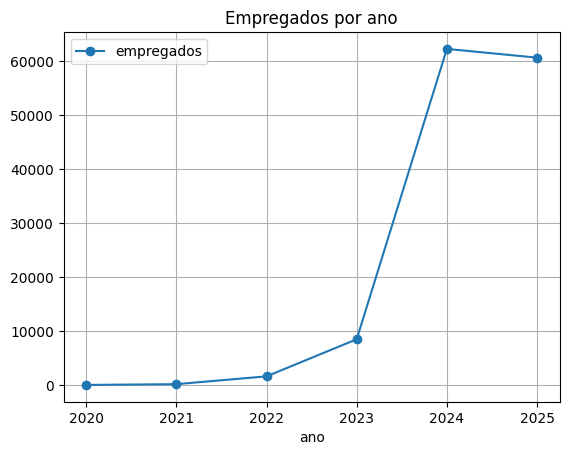

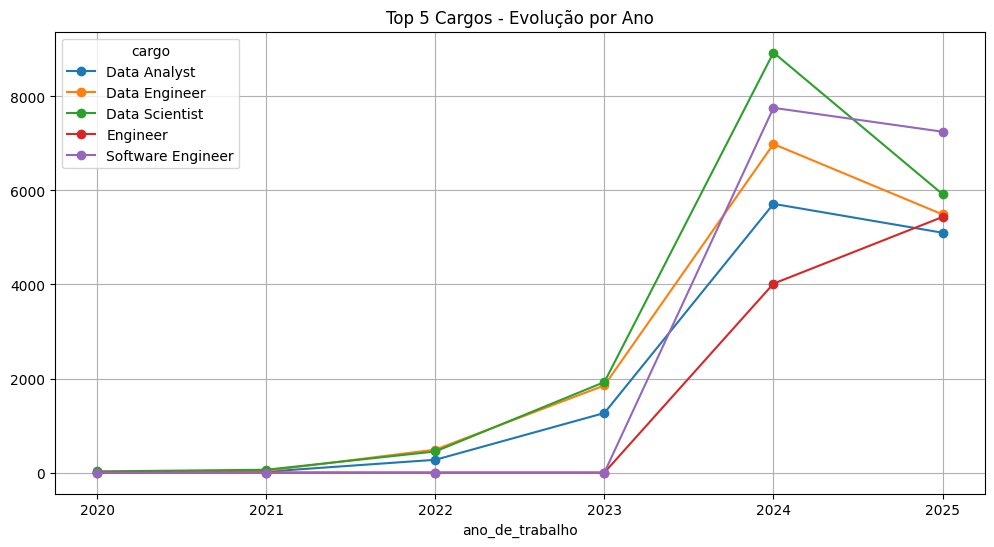

In [30]:
anos_df = pd.DataFrame(list(anos.items()), columns=["ano", "empregados"])
ax = anos_df.plot(x="ano", y="empregados", kind="line", marker="o", title="Empregados por ano")
ax.grid(True)

top_cargos = data['cargo'].value_counts().head(5).index
dados_filtrados = data[data['cargo'].isin(top_cargos)]
contagem_filtrada = dados_filtrados.groupby(['ano_de_trabalho', 'cargo']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
grafico_top = contagem_filtrada.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Top 5 Cargos - Evolução por Ano')
plt.grid(True)
plt.show()